In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# same einstein image as q9
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [7]:
# manual bilateral filter — pure numpy, no cv2
# space_w is precomputed once outside the loop (its the same for every pixel)
# range_w changes per pixel because it depends on intensity difference from the centre
def bilateral_filter(img, d, sigma_s, sigma_r):
    h, w   = img.shape
    pad    = d // 2
    padded = np.pad(img.astype(np.float64), pad, mode='reflect')
    out    = np.zeros_like(img, dtype=np.float64)

    ys, xs = np.mgrid[-pad:pad+1, -pad:pad+1]
    space_w = np.exp(-(xs**2 + ys**2) / (2 * sigma_s**2))

    for i in range(h):
        for j in range(w):
            region   = padded[i:i+d, j:j+d]
            center   = padded[i+pad, j+pad]
            range_w  = np.exp(-((region - center)**2) / (2 * sigma_r**2))
            weights  = space_w * range_w
            out[i,j] = np.sum(weights * region) / np.sum(weights)

    return np.clip(out, 0, 255).astype(np.uint8)

In [8]:
# resize down to 128x134 so the manual filter doesnt take forever
full = cv2.imread(os.path.join(IMG_DIR, 'einstein.png'), cv2.IMREAD_GRAYSCALE)
img  = cv2.resize(full, (128, 134))

In [ ]:
# sigma_s=3 gives real spatial decay inside the 9x9 window (corner weight ~0.17 vs centre 1.0)
# using sigma_s=75 would flatten the spatial kernel and turn bilateral into a pure range filter
# gaussian sigma=3 matches the kernel size properly; sigma=1.5 truncates the gaussian too much and gives a worse result
gauss_out    = cv2.GaussianBlur(img, (9, 9), 3)
cv_bilateral = cv2.bilateralFilter(img, 9, 75, 75)
my_bilateral = bilateral_filter(img, 9, 3, 75)


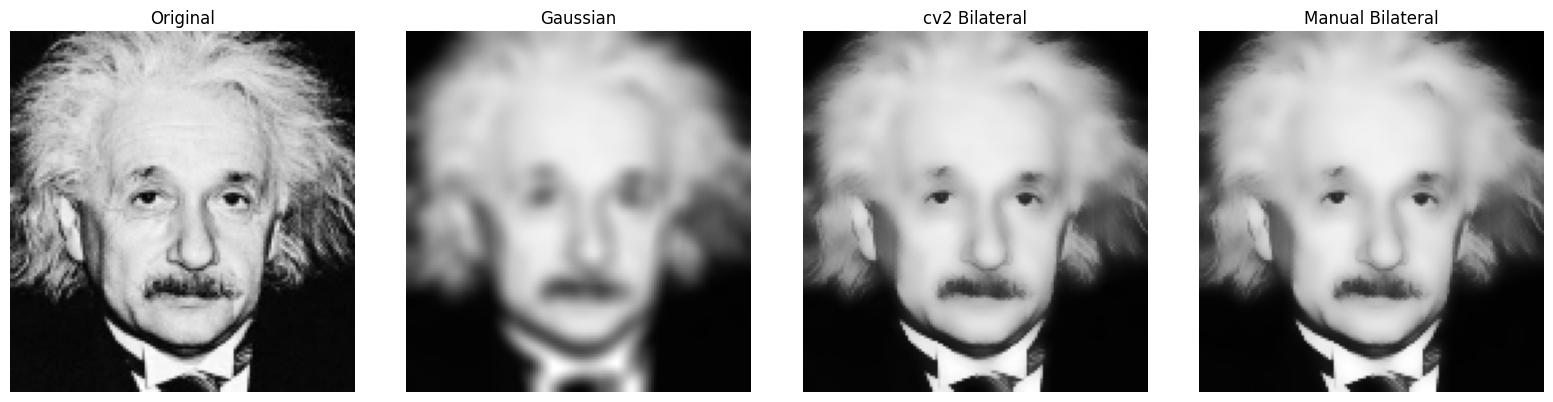

In [10]:
# four-way plot: original, gaussian blur, cv2 bilateral, and the manual one
# should show that bilateral keeps edges sharp while gaussian smears them
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes,
                     [img, gauss_out, cv_bilateral, my_bilateral],
                     ['Original', 'Gaussian', 'cv2 Bilateral', 'Manual Bilateral']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q10_bilateral.png'), dpi=150)
plt.show()